# Landslide susceptibility, Rangamati Hill Tracts

**Undergraduate thesis, Chittagong University of Engineering & Technology.**

This notebook is the argument of the project in the order the evidence actually arrived. It is
meant to be read top to bottom and it is meant to be re-runnable: every number printed below is
computed here, not quoted from somewhere else.

The original work trained a classifier on an inventory of 392 sites and served it from a web
application that returned a landslide probability for any coordinate the user clicked. **The
inventory is not mine.** It traces back to fieldwork by Rabby and Li, who mapped landslides across
the Chittagong Hilly Areas from Google Earth imagery and field survey
([10.3390/data5010004](https://doi.org/10.3390/data5010004), CC BY), and to the Rangamati
susceptibility study of Rabby, Hossain and Abedin
([10.1080/10106049.2020.1864026](https://doi.org/10.1080/10106049.2020.1864026)). The CSV read
here was published by Inan and Rahman
([10.1007/s42979-023-01960-5](https://doi.org/10.1007/s42979-023-01960-5)) under MIT, and the copy
in this repository matches theirs byte for byte. Full chain in `DATA_SOURCES.md`.

Restructuring the project turned up four things worth writing down, and they are the spine of
this notebook:

1. **The training columns are not measurements.** They are reclassified class ratings, and the
   deployed application was feeding the model raw satellite readings instead. Every live answer
   was computed from inputs the model had never seen.
2. **The model comparison was not stable.** Nine models were ranked on one 75/25 split. Change the
   seed and the ranking changes.
3. **So accuracy could not choose the model, and something else had to.** That problem is what the
   TOS paper came out of, and TOS is what selects the model here.
4. **The output is not a probability of failure.** The inventory is balanced by construction, so
   the number ranks sites against each other and overstates absolute risk.

Two things that did not work in the original are fixed: the app no longer needs a Google Earth
Engine credential to start, and live coordinate lookup produces inputs the model can actually
interpret.

In [1]:
import json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .6,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
MOSS, CLAY, AMBER, SAND = "#3F6B4A", "#A8452C", "#B5791E", "#C7BFAC"

# Print the repository NAME, never the absolute path: this notebook is committed, and an
# absolute path publishes the directory layout of whatever machine last ran it.
print("repository :", ROOT.name)
print("pandas", pd.__version__, "| numpy", np.__version__)

repository : landslide-prediction
pandas 3.0.5 | numpy 2.4.4


---
## 1. The inventory

392 sites, balanced 196 landslide and 196 non-landslide **by construction**. That balance is a
sampling decision, not a property of the terrain, and it comes back in section 6.

One thing to keep in view while reading the rest: the inventory is reused, not collected here
(see the header above). The study area is Rangamati District, Bangladesh, which the upstream
susceptibility paper states and which the boundary polygon used from section 7 onward
corroborates independently at 5,782 km² against the district's ~6,116 km² of record. What no
published source documents is which inventory records became which of these 392 rows.

In [2]:
df = pd.read_csv(ROOT / "data" / "landslide_inventory.csv")
print("rows %d, columns %d" % df.shape)
print("landslide %d | non-landslide %d" % (int(df.Y.sum()), int((1 - df.Y).sum())))
df.head()

rows 392, columns 16
landslide 196 | non-landslide 196


,Y,PROFILE,PLAN,CHANGE,LANDUSE,ELEVATION,SLOPE,ASPECT,TWI,SPI,DRAINAGE,NDVI,RAINFALL,FAULTLINES,ROAD,GEOLOGY
0,1,38,43,2,10,11,22,7,45,24,36,16,29,32,88,18
1,1,57,52,2,10,26,31,11,30,23,12,22,29,28,88,10
2,1,57,52,2,10,26,31,11,45,30,17,36,29,28,88,10
3,1,38,43,2,10,26,6,7,16,23,17,22,29,28,88,10
4,1,38,43,2,10,26,31,15,45,30,17,36,29,28,88,10


---
## 2. The training columns are not measurements

This is the serious finding, and it is visible directly in the data. `SLOPE` is not an angle in
degrees: across all 392 rows it takes **five** distinct integers. `ELEVATION` takes **four**, none
of which is a plausible height in metres for a district that runs from about 30 m to 840 m.

They are class ratings from a weighted-overlay reclassification: each factor was cut into classes
and each class given a score. The giveaway is the column on the right below.

In [3]:
rows = []
for c in df.columns:
    if c == "Y":
        continue
    vals = sorted(int(v) for v in df[c].dropna().unique())
    rate = [round(float(df.loc[df[c] == v, "Y"].mean()), 2) for v in vals]
    rows.append({"factor": c, "classes": len(vals), "ratings": str(vals),
                 "ratings sum to": sum(vals), "landslide rate per class": str(rate)})
audit = pd.DataFrame(rows)
audit

,factor,classes,ratings,ratings sum to,landslide rate per class
0,PROFILE,3,"[5, 38, 57]",100,"[0.06, 0.49, 0.69]"
1,PLAN,3,"[5, 43, 52]",100,"[0.05, 0.58, 0.62]"
2,CHANGE,10,"[0, 1, 2, 4, 5, 6, 9, 14, 21, 23]",85,"[0.0, 0.22, 0.6, 0.5, 0.57, 0.5, 0.72, 0.86, 0.7, 0.75]"
3,LANDUSE,4,"[0, 10, 29, 61]",100,"[0.0, 0.6, 0.62, 0.78]"
4,ELEVATION,4,"[11, 13, 26, 50]",100,"[0.24, 0.88, 0.68, 0.82]"
5,SLOPE,5,"[6, 13, 22, 28, 31]",100,"[0.12, 0.62, 1.0, 1.0, 1.0]"
6,ASPECT,8,"[2, 7, 10, 11, 13, 14, 15, 17]",89,"[0.14, 0.47, 0.41, 0.53, 0.62, 0.64, 0.57, 0.61]"
7,TWI,5,"[0, 9, 16, 30, 45]",100,"[0.0, 0.12, 0.2, 0.46, 0.96]"
8,SPI,6,"[0, 6, 17, 23, 24, 30]",100,"[0.0, 0.14, 0.36, 0.69, 0.49, 0.56]"
9,DRAINAGE,6,"[0, 8, 12, 17, 27, 36]",100,"[0.0, 0.39, 0.42, 0.43, 0.68, 0.59]"


**Every factor's ratings sum to 100.** That is a normalisation, not a coincidence, and it settles
what these columns are. Two exceptions are informative rather than contradictory: `ASPECT` sums to
89 and `CHANGE` to 85, which means those factors have classes that simply never occur among the
392 sampled sites. For aspect, one missing class of weight 11 is exactly the usual
flat-plus-eight-octants scheme with one octant unsampled.

The right-hand column shows the second recoverable fact: **within every factor, the rating rises
with the observed landslide rate.** So the ratings are an ordering, from least to most
susceptible, and the order is known even though the cut points were never recorded.

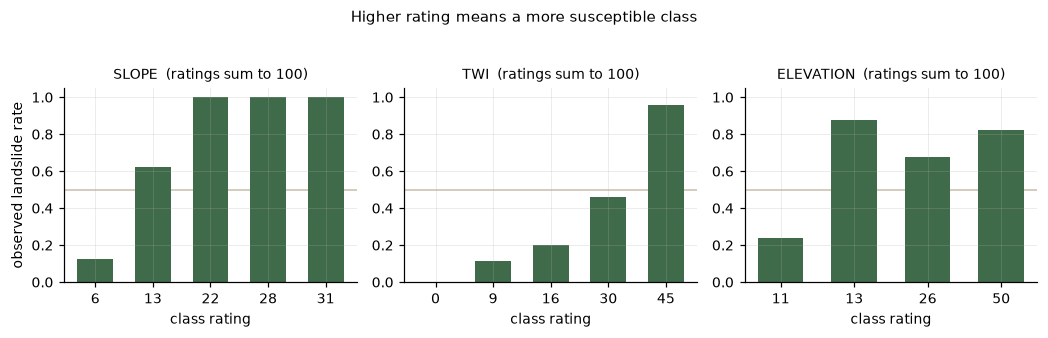

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.9))
for ax, f in zip(axes, ["SLOPE", "TWI", "ELEVATION"]):
    vals = sorted(int(v) for v in df[f].unique())
    rate = [float(df.loc[df[f] == v, "Y"].mean()) for v in vals]
    ax.bar([str(v) for v in vals], rate, color=MOSS, width=.62)
    ax.set_title("%s  (ratings sum to %d)" % (f, sum(vals)), fontsize=9)
    ax.set_xlabel("class rating"); ax.set_ylim(0, 1.05)
    ax.axhline(.5, color=SAND, lw=1, zorder=0)
axes[0].set_ylabel("observed landslide rate")
fig.suptitle("Higher rating means a more susceptible class", y=1.04, fontsize=10)
fig.tight_layout(); plt.show()

### Why this broke the deployed application

The original `app.py` sampled Google Earth Engine and passed the readings straight to the model:
elevation in metres, slope in degrees, NDVI as a ratio in [-1, 1]. Compare those against the
ranges the model was actually trained on.

In [5]:
FEATURES = ["ELEVATION", "SLOPE", "ASPECT", "TWI", "SPI", "NDVI", "RAINFALL", "LANDUSE"]

# what the original handler produced for a point near Rangamati town
raw_reading = {"ELEVATION": 213, "SLOPE": 0.94, "ASPECT": 140.47,
               "TWI": 10.0, "SPI": 0.02, "NDVI": 0.52, "RAINFALL": 28, "LANDUSE": 8}

chk = []
for f in FEATURES:
    lo, hi = float(df[f].min()), float(df[f].max())
    v = raw_reading[f]
    chk.append({"feature": f, "trained range": "%g to %g" % (lo, hi), "raw reading": v,
                "inside?": "yes" if lo <= v <= hi else "NO"})
pd.DataFrame(chk)

,feature,trained range,raw reading,inside?
0,ELEVATION,11 to 50,213.00,NO
1,SLOPE,6 to 31,0.94,NO
2,ASPECT,2 to 17,140.47,NO
3,TWI,0 to 45,10.00,yes
4,SPI,0 to 30,0.02,yes
5,NDVI,0 to 36,0.52,yes
6,RAINFALL,0 to 35,28.00,yes
7,LANDUSE,0 to 61,8.00,yes


Six of the eight land outside the range the model has ever seen. scikit-learn raises nothing when
asked to extrapolate, so the page returned a confident percentage computed from numbers it could
not interpret. Section 7 builds the conversion that was missing.

---
## 3. The original ranking was mostly noise

The thesis reported "Accuracy of Random Forest on test set: 0.88" from a single 75/25 split with
the default seed. With 392 rows the test set holds 98 samples, so one percentage point is one
sample. Here is the same comparison repeated over 40 different seeds.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X, y = df[FEATURES], df["Y"].astype(int)

contenders = {
    "Random forest": lambda: RandomForestClassifier(n_estimators=300, max_depth=5, random_state=0),
    "Gradient boosting": lambda: GradientBoostingClassifier(random_state=0),
    "Logistic regression": lambda: Pipeline([("s", StandardScaler()),
                                             ("m", LogisticRegression(max_iter=2000))]),
}

seeds = range(40)
scores = {k: [] for k in contenders}
winners = []
for sd in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, random_state=sd, stratify=y)
    best, best_s = None, -1
    for name, make in contenders.items():
        m = make().fit(Xtr, ytr)
        s = m.score(Xte, yte)
        scores[name].append(s)
        if s > best_s:
            best, best_s = name, s
    winners.append(best)

for name, ss in scores.items():
    print("%-20s accuracy %.3f to %.3f  (spread %.3f)" % (name, min(ss), max(ss), max(ss) - min(ss)))
print()
print("which model 'won' the single split, over 40 seeds:")
for k, v in pd.Series(winners).value_counts().items():
    print("   %-20s %2d / 40" % (k, v))

Random forest        accuracy 0.837 to 0.929  (spread 0.092)
Gradient boosting    accuracy 0.827 to 0.939  (spread 0.112)
Logistic regression  accuracy 0.857 to 0.939  (spread 0.082)

which model 'won' the single split, over 40 seeds:
   Gradient boosting    20 / 40
   Logistic regression  11 / 40
   Random forest         9 / 40


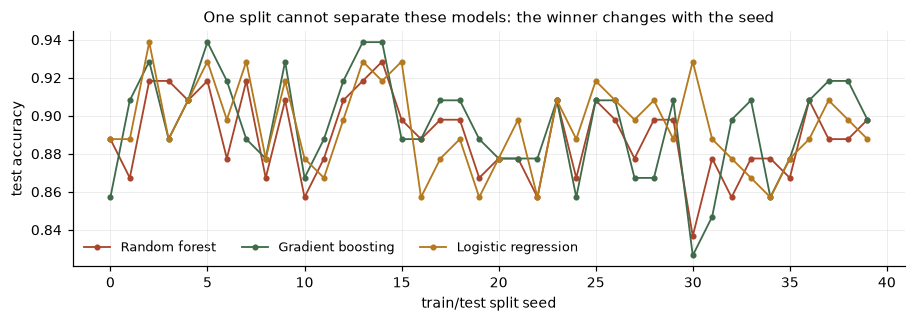

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 3.0))
for name, col in zip(scores, [CLAY, MOSS, AMBER]):
    ax.plot(list(seeds), scores[name], marker="o", ms=3, lw=1.2, color=col, label=name)
ax.set_xlabel("train/test split seed"); ax.set_ylabel("test accuracy")
ax.set_title("One split cannot separate these models: the winner changes with the seed", fontsize=10)
ax.legend(frameon=False, ncol=3, fontsize=8.5)
fig.tight_layout(); plt.show()

The lines cross constantly. Reporting the winner of one split reports the seed, not the model.

---
## 4. A comparison that holds still, and a baseline the original did not have

Repeated stratified cross-validation, 5 folds by 6 repeats, so 30 fits per model. A
most-frequent-class baseline is included because without it there is no way to know whether 0.88
is a real result or a property of the data.

In [8]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
sys.path.insert(0, str(ROOT / "src"))
from train import build_models, BASELINE

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=0)
scoring = {"accuracy": "accuracy", "roc_auc": "roc_auc", "recall": "recall", "f1": "f1"}

rows = []
for name, model in build_models().items():
    r = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({"model": name,
                 "accuracy": r["test_accuracy"].mean(), "sd": r["test_accuracy"].std(),
                 "recall": r["test_recall"].mean(), "roc_auc": r["test_roc_auc"].mean()})
lb = pd.DataFrame(rows)
lb["fnr"] = 1 - lb["recall"]
lb.sort_values("accuracy", ascending=False).round(4).reset_index(drop=True)

,model,accuracy,sd,recall,roc_auc,fnr
0,Gradient boosting,0.8929,0.0260,0.8860,0.9660,0.1140
1,Logistic regression,0.8899,0.0353,0.8664,0.9517,0.1336
2,Random forest,0.8886,0.0287,0.8673,0.9636,0.1327
3,Support vector machine,0.8865,0.0295,0.8410,0.9487,0.1590
4,k-nearest neighbours,0.8822,0.0310,0.8299,0.9315,0.1701
5,AdaBoost,0.8780,0.0344,0.8596,0.9513,0.1404
6,Decision tree,0.8687,0.0363,0.8374,0.9312,0.1626
7,Baseline (most frequent),0.4975,0.0031,0.2000,0.5000,0.8000


Every candidate above the baseline sits inside about one standard deviation of every other, and
the top few are separated by roughly three thousandths of accuracy: far less than the 0.03 spread
of the folds. **Plain logistic regression matches the ensembles**, which says the signal in these
eight factors is close to linearly separable and an interpretable model costs nothing here.

The baseline lands at 0.497, so 0.88 is real.

---
## 5. Selecting the model with TOS

Accuracy cannot separate these candidates, and it also cannot express the thing that matters most
here: **a missed landslide and a false alarm are not equally expensive.** Picking the largest
accuracy silently declares that they are.

This is the problem that produced the paper behind this project, *TOS: A Relative Metric Approach
for Model Selection in Machine Learning Solutions* (IEEE RAAICON 2021). TOS scores each candidate
against the others actually on the table, on two axes that have to be named:

$$\mathrm{TOS}_i = \tfrac{1}{2}\left(\tanh z_{\mathrm{acc},i} - \tanh z_{\mathrm{err},i}\right)$$

The accuracy axis is cross-validated accuracy. The error axis is the **false negative rate**,
because the expensive mistake in susceptibility mapping is the landslide you did not predict.

In [9]:
from tos import rank, pool_sensitivity

pool = lb[lb.model != BASELINE]
names = list(pool.model)
acc = [float(v) for v in pool.accuracy]
fnr = [float(v) for v in pool.fnr]

ranking = rank(names, acc, fnr)
print("%-24s %8s %9s %8s" % ("model", "TOS", "accuracy", "FNR"))
for n, s, a, e in ranking:
    print("%-24s %+8.4f %9.4f %8.4f" % (n, s, a, e))

selected = ranking[0][0]
print("\nselected by TOS      :", selected)
print("accuracy would choose:", lb.sort_values("accuracy", ascending=False).iloc[0].model)
print("ROC AUC would choose :", lb.sort_values("roc_auc", ascending=False).iloc[0].model)

model                         TOS  accuracy      FNR
Gradient boosting         +0.8771    0.8929   0.1140
Logistic regression       +0.5969    0.8899   0.1336
Random forest             +0.5606    0.8886   0.1327
Support vector machine    -0.1584    0.8865   0.1590
AdaBoost                  -0.2075    0.8780   0.1404
k-nearest neighbours      -0.5420    0.8822   0.1701
Decision tree             -0.8551    0.8687   0.1626

selected by TOS      : Gradient boosting
accuracy would choose: Gradient boosting
ROC AUC would choose : Gradient boosting


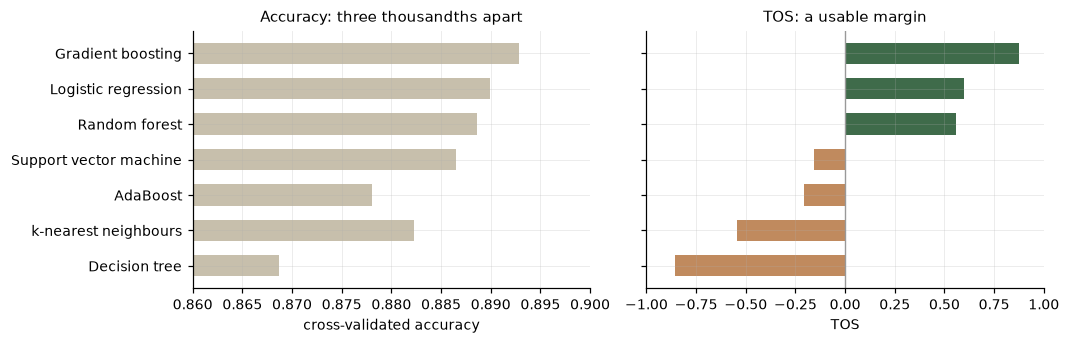

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.2))
nm = [r[0] for r in ranking][::-1]
tv = [r[1] for r in ranking][::-1]
av = [r[2] for r in ranking][::-1]

axes[0].barh(nm, [a - .86 for a in av], left=.86, color=SAND, height=.6)
axes[0].set_xlim(.86, .90); axes[0].set_title("Accuracy: three thousandths apart", fontsize=9.5)
axes[0].set_xlabel("cross-validated accuracy")

axes[1].barh(nm, tv, color=[MOSS if v >= 0 else "#C08A5E" for v in tv], height=.6)
axes[1].axvline(0, color="#999", lw=.9)
axes[1].set_xlim(-1, 1); axes[1].set_title("TOS: a usable margin", fontsize=9.5)
axes[1].set_xlabel("TOS")
axes[1].set_yticklabels([])
fig.tight_layout(); plt.show()

### The limitation, demonstrated rather than described

TOS is computed **across the pool**, so it is not independent of irrelevant alternatives: adding a
candidate that can never win may still reorder the candidates above it. That is a real property of
the metric and this dataset shows it.

The baseline is the perfect irrelevant alternative. Nobody would deploy it. Watch what putting it
back into the pool does.

In [11]:
order_without = [n for n, _, _, _ in ranking]
with_base = rank(list(lb.model), [float(v) for v in lb.accuracy], [float(v) for v in lb.fnr])
order_with = [n for n, _, _, _ in with_base if n != BASELINE]

print("%-4s %-24s %-24s" % ("rank", "pool of 7 (deployable)", "pool of 8 (+ baseline)"))
for i, (a, b) in enumerate(zip(order_without, order_with), 1):
    flag = "   <-- moved" if a != b else ""
    print("%-4d %-24s %-24s%s" % (i, a, b, flag))

print("\nwinner unchanged      :", order_without[0] == order_with[0])
print("order otherwise changed:", order_without != order_with)
print("\nwinner if the weakest candidates are dropped:")
for t in pool_sensitivity(names, acc, fnr)["trials"]:
    print("   pool of %d -> %s (TOS %+.4f)" % (t["pool_size"], t["winner"], t["tos"]))

rank pool of 7 (deployable)   pool of 8 (+ baseline)  
1    Gradient boosting        Gradient boosting       
2    Logistic regression      Logistic regression     
3    Random forest            Random forest           
4    Support vector machine   AdaBoost                   <-- moved
5    AdaBoost                 Support vector machine     <-- moved
6    k-nearest neighbours     k-nearest neighbours    
7    Decision tree            Decision tree           

winner unchanged      : True
order otherwise changed: True

winner if the weakest candidates are dropped:
   pool of 7 -> Gradient boosting (TOS +0.8771)
   pool of 6 -> Gradient boosting (TOS +0.8855)
   pool of 5 -> Gradient boosting (TOS +0.8792)
   pool of 4 -> Gradient boosting (TOS +0.8807)


The winner holds, and it holds when the weakest candidates are dropped, so the selection is not an
artefact. But two candidates **do** swap places purely because a model nobody would ship joined the
pool. A relative score is only meaningful next to the pool it was computed over, which is why
`reports/metrics.json` always records the pool alongside the ranking.

---
## 6. Out of fold, and what the number is not

Out-of-fold predictions give an honest confusion matrix: every prediction below was made by a
model that had not seen that row.

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

best = build_models()[selected]
cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=0)
proba = cross_val_predict(best, X, y, cv=cv1, method="predict_proba", n_jobs=-1)[:, 1]
pred = (proba >= .5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, pred).ravel()

print("out-of-fold, threshold 0.5")
print("   caught            %4d" % tp)
print("   MISSED landslides %4d" % fn)
print("   false alarms      %4d" % fp)
print("   correct negatives %4d" % tn)
print("   ROC AUC %.3f | Brier %.3f" % (roc_auc_score(y, proba), brier_score_loss(y, proba)))

out-of-fold, threshold 0.5
   caught             174
   MISSED landslides   22
   false alarms        18
   correct negatives  178
   ROC AUC 0.965 | Brier 0.075


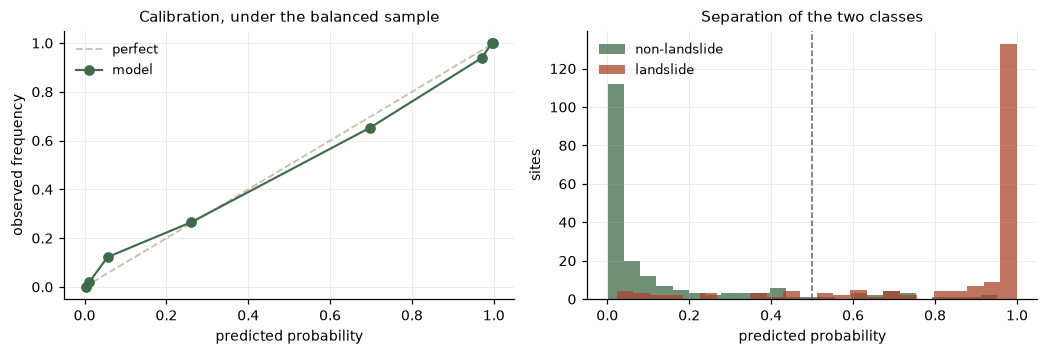

In [13]:
frac_pos, mean_pred = calibration_curve(y, proba, n_bins=8, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.3))
axes[0].plot([0, 1], [0, 1], "--", color=SAND, lw=1.2, label="perfect")
axes[0].plot(mean_pred, frac_pos, marker="o", color=MOSS, lw=1.4, label="model")
axes[0].set_xlabel("predicted probability"); axes[0].set_ylabel("observed frequency")
axes[0].set_title("Calibration, under the balanced sample", fontsize=9.5)
axes[0].legend(frameon=False, fontsize=8.5)

axes[1].hist(proba[y == 0], bins=24, alpha=.75, color=MOSS, label="non-landslide")
axes[1].hist(proba[y == 1], bins=24, alpha=.75, color=CLAY, label="landslide")
axes[1].axvline(.5, color="#666", lw=1, ls="--")
axes[1].set_xlabel("predicted probability"); axes[1].set_ylabel("sites")
axes[1].set_title("Separation of the two classes", fontsize=9.5)
axes[1].legend(frameon=False, fontsize=8.5)
fig.tight_layout(); plt.show()

The calibration line is close to the diagonal, but that diagonal is **calibrated to a 50/50
world**. The inventory holds 196 landslide and 196 non-landslide sites because it was built that
way; real hillsides fail far less often.

So the model's output is a **ranking of sites against each other, not a probability that a given
hillside will fail.** Reading 0.8 as a four-in-five chance of collapse would be a serious error in
the one setting where this work could matter. Converting it to a real risk needs the true base
rate, which this dataset does not record.

There is also an inconsistency worth naming: the 0.5 threshold that produced the confusion matrix
above treats a missed landslide and a false alarm as equally costly, while the selection rule in
section 5 explicitly does not. Making the threshold answer to the same cost asymmetry is the
clearest next piece of work.

---
## 7. Rebuilding the bridge from measurement to class rating

Section 2 showed the model cannot read a raw satellite reading. The conversion table was never
recorded in the first version, so `src/reclassify.py` reconstructs it. What is recoverable,
and what is assumed:

| | source |
|---|---|
| how many classes each factor has | the ratings sum to 100 (section 2) |
| the order of the classes | rating rises with landslide rate (section 2) |
| **where one class stops and the next begins** | **assumed**: standard physical breaks |

The study area came out of the repository too. An undocumented file called `coordinates_3` held
11,774 bare `lon,lat` pairs; they form a single closed ring enclosing 5,782 km², which identifies
it as the Rangamati district boundary rather than a list of sample sites.

In [14]:
import study_area, reclassify

print("study area : %s" % json.loads(
    (ROOT / "data" / "study_area.json").read_text(encoding="utf-8"))["name"])
print("area       : %.0f km2  (district of record: about 6,116 km2)" % study_area.area_km2())

b = reclassify.breaks()
print("\nclass cut points")
for k in ("SLOPE", "ELEVATION"):
    print("   %-10s %d classes, cuts at %s" % (k, len(reclassify.RATINGS[k]), b[k]))
    print("   %-10s share of the district in each class: %s"
          % ("", b["district_share"][k]))

print("\nheld fixed, because a point query cannot measure them:")
for k, v in reclassify.DEFAULTS.items():
    print("   %-9s = %-3s  %s" % (k, v["value"], v["why"][:58]))

study area : Rangamati Hill District, Bangladesh
area       : 5782 km2  (district of record: about 6,116 km2)

class cut points
   SLOPE      5 classes, cuts at [5.0, 15.0, 25.0, 35.0]
              share of the district in each class: [0.446, 0.362, 0.162, 0.031, 0.0]
   ELEVATION  4 classes, cuts at [100.0, 300.0, 500.0]
              share of the district in each class: [0.512, 0.4, 0.046, 0.042]

held fixed, because a point query cannot measure them:
   TWI       = 16   needs catchment flow accumulation, which a single point ca
   SPI       = 17   needs catchment flow accumulation, which a single point ca
   NDVI      = 16   needs Landsat NDVI; held at the middle vegetation class
   RAINFALL  = 21   no rainfall grid cached; run python src/rainfall.py to mea
   LANDUSE   = 29   hill forest, the dominant cover of the district; needs MOD


An earlier version of this file placed the cut points at **quantiles of the district's own
terrain**, so each class would cover an equal share of the ground. That is defensible in the
abstract and wrong here, for a reason worth keeping: the inventory is balanced 196/196 by design
and is therefore **not a random sample of the district**. Its slope class 22 has a 1.00 observed
landslide rate. Mapping the district's median hillside into that class declared half of Rangamati
a certainty and every coordinate came back above 0.96. Quantile matching only works when both
distributions describe the same population.

---
## 8. A live coordinate, end to end

The feature the project exists for. Elevation comes from [SRTM 30 m](https://doi.org/10.5066/F7PR7TFT)
through [OpenTopoData](https://www.opentopodata.org/datasets/srtm/), a public endpoint that needs
no account; slope and aspect are computed from a 3×3 window by Horn's method; the result is
converted to class ratings and scored.

*This cell makes network requests.*

In [15]:
import terrain
from predict import predict_one

sites = [("Sajek ridge",        23.3800, 92.2900),
         ("Rangamati town",     22.6533, 92.1750),
         ("Kaptai lake shore",  22.4950, 92.2200),
         ("Dhaka (outside)",    23.8103, 90.4125)]

out = []
for name, lat, lon in sites:
    if not study_area.contains(lat, lon):
        out.append({"site": name, "elev m": None, "slope deg": None,
                    "probability": None, "band": "REFUSED, outside the study area"})
        continue
    raw = terrain.sample_point(lat, lon)
    conv = reclassify.reclassify(raw)
    res = predict_one(conv["features"])
    out.append({"site": name,
                "elev m": round(raw["ELEVATION_m"]),
                "slope deg": round(raw["SLOPE_deg"], 2),
                "probability": round(res["probability"], 3),
                "band": res["band"],
                "out-of-domain warnings": len(res["warnings"])})
pd.DataFrame(out)

,site,elev m,slope deg,probability,band,out-of-domain warnings
0,Sajek ridge,291.0,16.14,0.995,Very high,0.0
1,Rangamati town,44.0,4.08,0.124,Very low,0.0
2,Kaptai lake shore,47.0,4.85,0.064,Very low,0.0
3,Dhaka (outside),NaN,NaN,NaN,"REFUSED, outside the study area",NaN


Zero out-of-domain warnings, which is the whole point of section 7: the values reaching the model
are now class ratings it recognises. The ordering is also physically sensible, with the lake shore
near the bottom and the 291 m ridge at the top.

A point outside Rangamati returns **no score at all**. The model has evidence about one district's
terrain; a number for anywhere else would be an extrapolation presented as a measurement.

Note what is measured and what is not. Only three of the eight predictors come from elevation, and
the other five are held at fixed classes, so the difference between two coordinates is
attributable to terrain.

In [16]:
raw = terrain.sample_point(23.3800, 92.2900)
conv = reclassify.reclassify(raw)
prov = pd.DataFrame([
    {"feature": k, "raw": v.get("raw"), "class rating": conv["features"][k],
     "measured": v.get("measured"), "source": v["from"][:52]}
    for k, v in conv["provenance"].items()])
imp = json.loads((ROOT / "reports" / "metrics.json").read_text(encoding="utf-8"))["feature_importance"]
prov["importance"] = prov.feature.map(imp).round(3)
print("measured share of total feature importance: %.3f"
      % sum(imp[k] for k in conv["measured"]))
prov

measured share of total feature importance: 0.819


,feature,raw,class rating,measured,source,importance
0,ELEVATION,291.00,13,True,SRTM 30m,0.070
1,SLOPE,16.14,22,True,Horn's method on a 90 m SRTM window,0.716
2,ASPECT,190.20,17,True,Horn's method,0.033
3,TWI,NaN,16,False,"needs catchment flow accumulation, which a single po",0.040
4,SPI,NaN,17,False,"needs catchment flow accumulation, which a single po",0.009
5,NDVI,NaN,16,False,needs Landsat NDVI; held at the middle vegetation cl,0.021
6,RAINFALL,NaN,21,False,no rainfall grid cached; run python src/rainfall.py,0.059
7,LANDUSE,NaN,29,False,"hill forest, the dominant cover of the district; nee",0.053


---
## 9. The susceptibility map

A coordinate answers "is this spot dangerous". The map answers "where is the danger", which is the
question anyone planning a road, a settlement or an evacuation route is actually asking, and it is
the artefact the thesis was aiming at.

`src/susceptibility_map.py` scores every cell of a grid laid over the district. It is cached,
because each cell needs its own elevation window from a shared public service.

In [17]:
gp = ROOT / "data" / "susceptibility_grid.json"
grid = json.loads(gp.read_text(encoding="utf-8"))
g = pd.DataFrame(grid["grid"], columns=grid["columns"])
inside = g[g.inside_district == 1]

sm = grid["summary"]
print("cells inside the district : %d at %.2f km" % (sm["cells"], sm["cell_km"]))
print("margin cells (for drawing): %d" % (sm["cells_with_margin"] - sm["cells"]))
print("median cell               : %.3f" % sm["median_probability"])
print("at 0.6 or above           : %.0f%%" % (sm["share_high"] * 100))
print("at 0.8 or above           : %.0f%%" % (sm["share_very_high"] * 100))

cells inside the district : 5067 at 1.11 km
margin cells (for drawing): 681
median cell               : 0.463
at 0.6 or above           : 41%
at 0.8 or above           : 23%


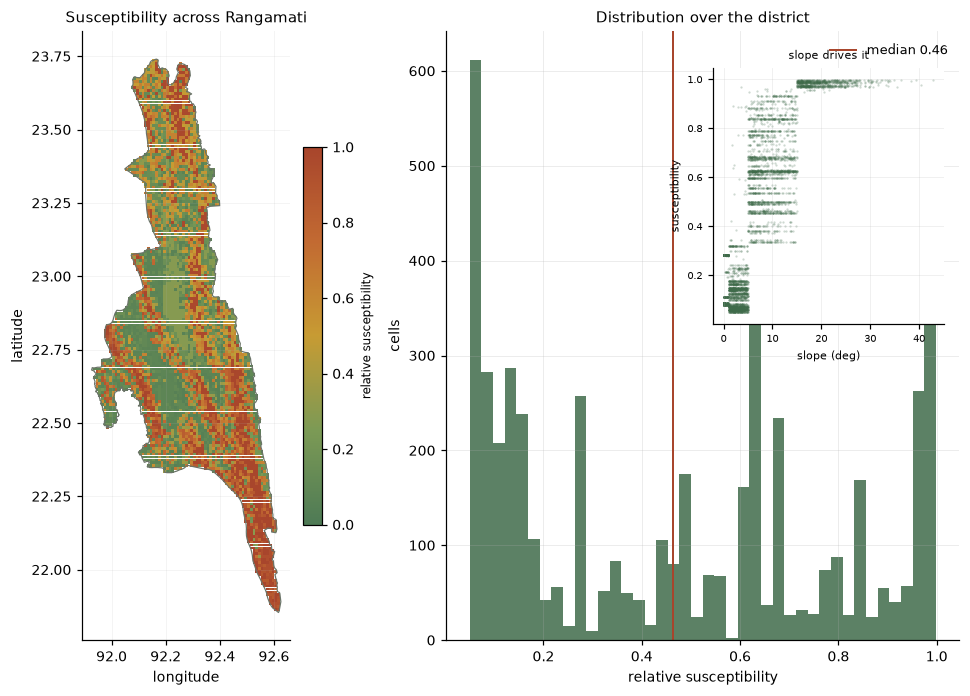

In [18]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "susceptibility", ["#4E7A55", "#7C9A55", "#C79B33", "#C26A32", "#A8452C"])

ring = np.array(study_area.ring())
fig, axes = plt.subplots(1, 2, figsize=(9.8, 6.4),
                         gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
sc = ax.scatter(inside.lon, inside.lat, c=inside.probability, cmap=cmap, s=3.4,
                vmin=0, vmax=1, marker="s", linewidths=0)
ax.plot(ring[:, 1], ring[:, 0], color="#6B7468", lw=.8)
ax.set_aspect(1 / np.cos(np.radians(22.7)))
ax.set_title("Susceptibility across Rangamati", fontsize=10)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.grid(alpha=.15)
cb = fig.colorbar(sc, ax=ax, fraction=.046, pad=.03)
cb.set_label("relative susceptibility", fontsize=8)

ax = axes[1]
ax.hist(inside.probability, bins=40, color=MOSS, alpha=.85)
ax.set_xlabel("relative susceptibility"); ax.set_ylabel("cells")
ax.set_title("Distribution over the district", fontsize=10)
ax.axvline(inside.probability.median(), color=CLAY, lw=1.3,
           label="median %.2f" % inside.probability.median())
ax.legend(frameon=False, fontsize=8.5)

sub = axes[1].inset_axes([.52, .52, .45, .42])
sub.scatter(inside.slope_deg, inside.probability, s=2.2, alpha=.25, color=MOSS, linewidths=0)
sub.set_xlabel("slope (deg)", fontsize=7.5); sub.set_ylabel("susceptibility", fontsize=7.5)
sub.tick_params(labelsize=6.5); sub.grid(alpha=.2)
sub.set_title("slope drives it", fontsize=7.5)

fig.tight_layout(); plt.show()

The high ground follows the eastern ridge lines and the low ground follows Kaptai Lake and the
valley floors, which is what the geomorphology says it should do. The inset makes the mechanism
explicit: slope carries 0.716 of the model's feature importance, and the map is largely a
transformation of slope.

The same caveat as section 6 applies with more force here, because a map invites being read as a
forecast. These are **relative rankings**. A red cell is more susceptible than a green one; it is
not a cell with an 80 percent chance of failing.

---
## 10. What I would attack next

In the order I would do them.

1. **Recover the real reclassification table.** Everything in sections 7 to 9 rests on assumed cut
   points. The class counts and ordering are solid; the boundaries are not. If the original
   ArcGIS project still exists, this is a lookup, not a research problem.
2. **Set the threshold with the same cost asymmetry the selection uses.** Choosing the model on a
   false-negative-weighted criterion and then thresholding at 0.5 is inconsistent (section 6).
3. **Calibrate to a real base rate.** Without it the output cannot be read as risk, only as rank.
4. **Measure TWI and SPI properly.** Both need catchment flow accumulation, which a point query
   cannot supply. A prepared flow-accumulation raster for the district would make them real
   inputs instead of held constants.
5. **Get more inventory.** 392 rows is the binding constraint on everything above: it is why one
   split could not separate nine models in the first place.

---

**Model selection.** Shaha, R., Talukder, D., Iqbal, M. A. and Haque, M. M. (2021). TOS: A
Relative Metric Approach for Model Selection in Machine Learning Solutions. *IEEE RAAICON*,
26-31. DOI [10.1109/raaicon54709.2021.9929722](https://doi.org/10.1109/raaicon54709.2021.9929722)

**Data.** Elevation:
[SRTM 30 m](https://doi.org/10.5066/F7PR7TFT) (`USGS/SRTMGL1_003`) served by
[OpenTopoData](https://www.opentopodata.org/datasets/srtm/). Rainfall:
[NASA POWER](https://power.larc.nasa.gov/) climatology
([PRECTOTCORR](https://power.larc.nasa.gov/docs/services/api/temporal/climatology/)). Map imagery:
[Esri World Imagery](https://www.arcgis.com/home/item.html?id=10df2279f9684e4a9f6a7f08febac2a9),
labels by [CARTO](https://carto.com/attributions) and
[OpenStreetMap](https://www.openstreetmap.org/copyright) contributors.

**Landslide inventory.** Original fieldwork: Rabby, Y. W. and Li, Y. (2020), *Data* 5(1), 4,
CC BY, [10.3390/data5010004](https://doi.org/10.3390/data5010004). Rangamati susceptibility study:
Rabby, Hossain and Abedin (2021), *Geocarto International*,
[10.1080/10106049.2020.1864026](https://doi.org/10.1080/10106049.2020.1864026). CSV as read here:
Inan and Rahman (2023), *SN Computer Science*,
[10.1007/s42979-023-01960-5](https://doi.org/10.1007/s42979-023-01960-5), MIT. Full chain and
licences in `DATA_SOURCES.md`.